In [185]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [186]:
df = pd.read_csv("../data/Divar.csv")

/tmp/ipykernel_309467/1449512079.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Divar.csv")


In [187]:
df_region = df.dropna(subset=["city_slug", "neighborhood_slug"]).copy()

In [188]:
df_region["region"] = (
    df_region["city_slug"].astype(str) + " / " + df_region["neighborhood_slug"].astype(str)
)

In [189]:
features = [
    "has_balcony",
    "has_elevator",
    "has_security_guard",
    "has_barbecue",
    "has_pool",
]

In [190]:
df_region["has_balcony"].value_counts()

has_balcony
true        185114
false        36700
True          9868
False         1953
unselect       103
Name: count, dtype: int64

In [191]:
df_region["has_elevator"].value_counts()

has_elevator
True     214934
False     93351
Name: count, dtype: int64

In [192]:
df_region["has_security_guard"].value_counts()

has_security_guard
False    3124
True       67
Name: count, dtype: int64

In [193]:
df_region["has_barbecue"].value_counts()

has_barbecue
False    3044
True      184
Name: count, dtype: int64

In [194]:
df_region["has_pool"].value_counts()

has_pool
False    3114
True       73
Name: count, dtype: int64

In [195]:
bool_map = {
    True: 1,
    False: 0,
    "true": 1,
    "false": 0,
    "True": 1,
    "False": 0,
    "TRUE": 1,
    "FALSE": 0,
    "1": 1,
    "0": 0,
    1: 1,
    0: 0
}

for col in features:
    df_region[col] = df_region[col].map(bool_map)

In [196]:
for col in features:
    print(col)
    print(df_region[col].value_counts(dropna=False))
    print("-" * 30)

has_balcony
has_balcony
NaN    203504
1.0    194982
0.0     38653
Name: count, dtype: int64
------------------------------
has_elevator
has_elevator
1.0    214934
NaN    128854
0.0     93351
Name: count, dtype: int64
------------------------------
has_security_guard
has_security_guard
NaN    433948
0.0      3124
1.0        67
Name: count, dtype: int64
------------------------------
has_barbecue
has_barbecue
NaN    433911
0.0      3044
1.0       184
Name: count, dtype: int64
------------------------------
has_pool
has_pool
NaN    433952
0.0      3114
1.0        73
Name: count, dtype: int64
------------------------------


In [197]:
mask = pd.Series(True, index=df_region.index)

for col in features:
    mask = mask & (df_region[col] == 1)
    print(col, mask.sum())

has_balcony 194982
has_elevator 123048
has_security_guard 0
has_barbecue 0
has_pool 0


In [198]:
feature_labels = {
    "has_balcony": "Balcony",
    "has_elevator": "Elevator",
    "has_security_guard": "Security Guard",
    "has_barbecue": "Barbecue",
    "has_pool": "Pool",
}

In [199]:
def get_top_regions_for_feature(df, feature, region_col="region", top_k=15):
    feature_df = df[df[feature] == 1].copy()
    
    top_regions = (
        feature_df
        .groupby(region_col)
        .size()
        .sort_values(ascending=False)
        .head(top_k)
    )
    
    return top_regions

In [200]:
def plot_top_regions_for_feature(df, feature, region_col="region", top_k=15):
    top_regions = get_top_regions_for_feature(
        df,
        feature,
        region_col,
        top_k
    )
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        x=top_regions.values,
        y=top_regions.index
    )
    
    plt.title(
        f"Top {top_k} regions for properties with {feature_labels[feature]}"
    )
    plt.xlabel("Number of listings")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()
    
    return top_regions

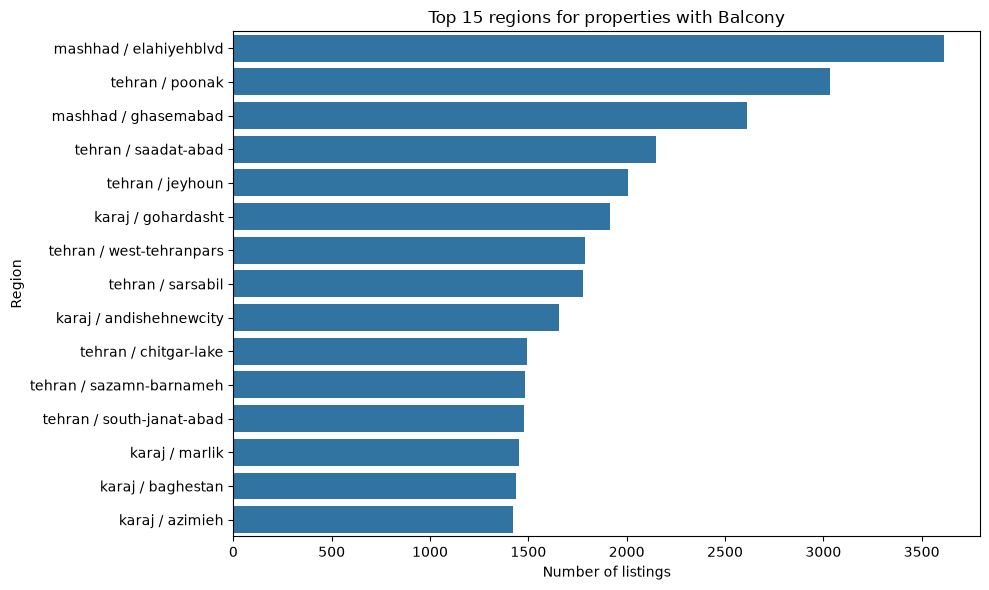

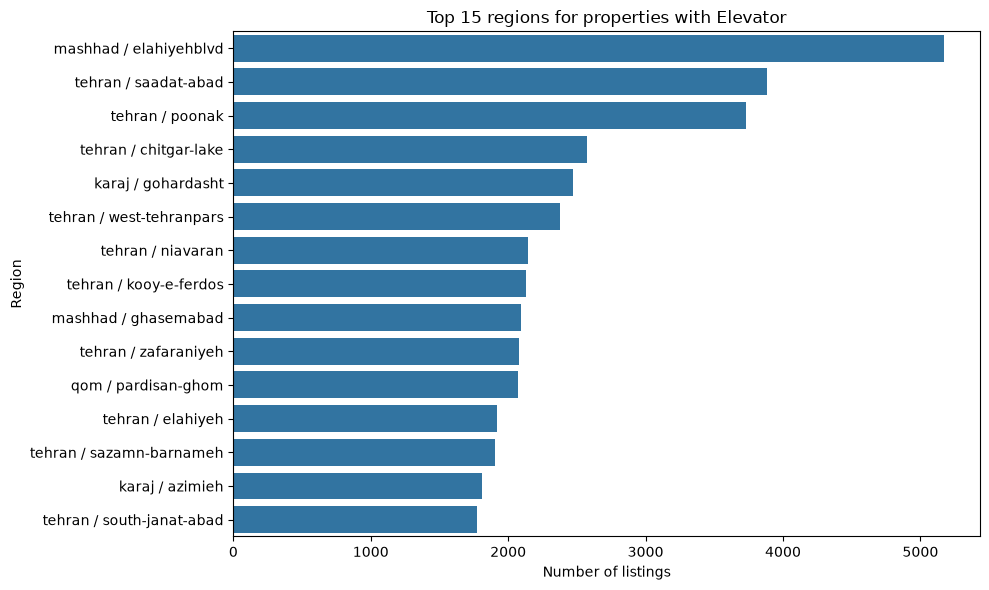

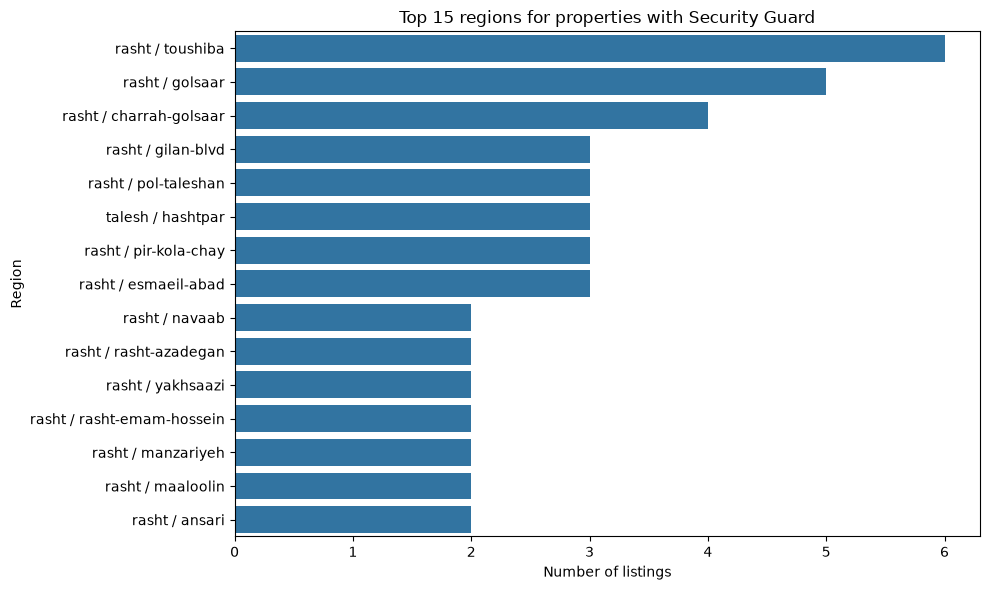

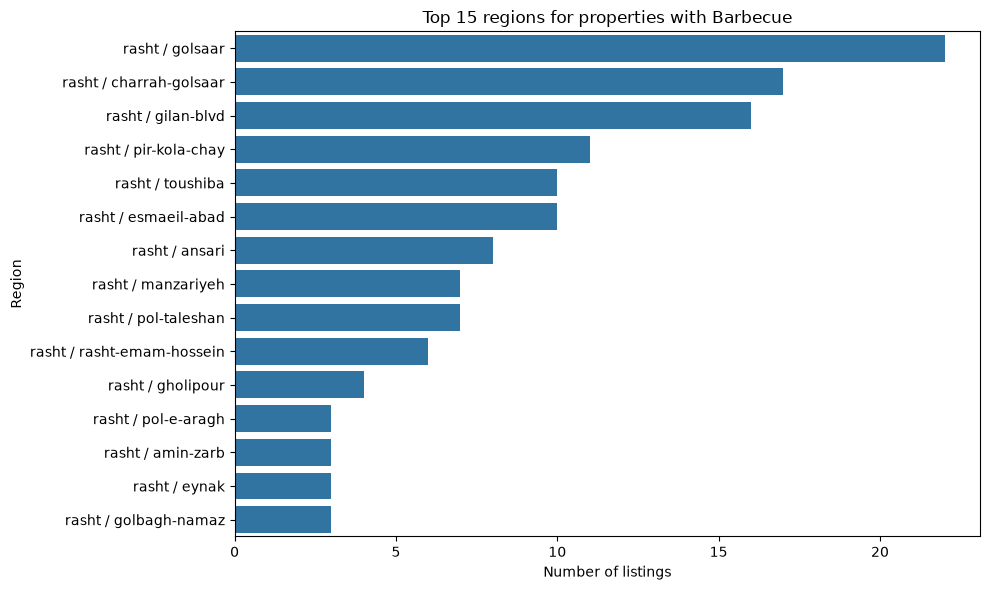

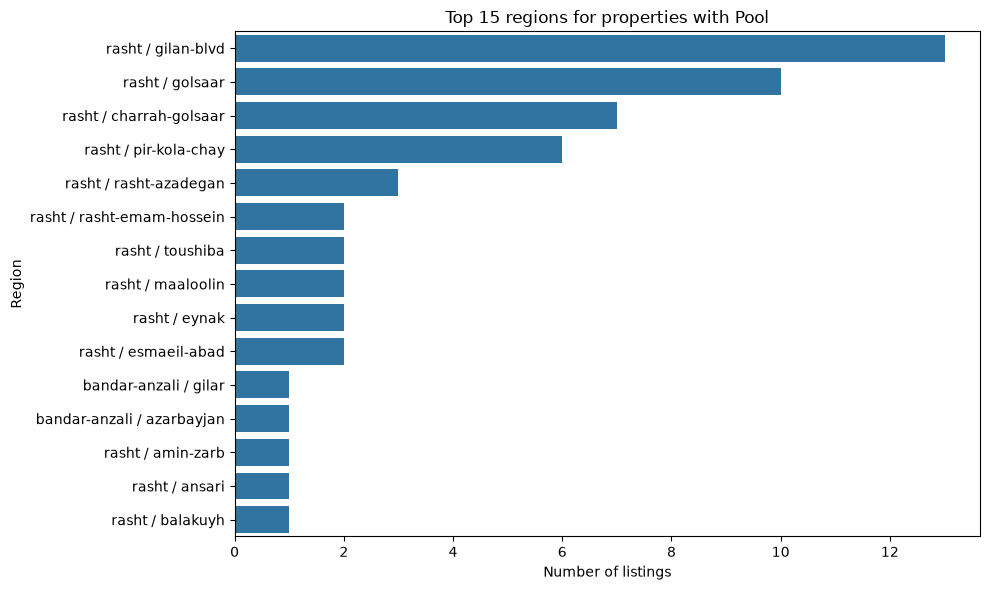

In [201]:
top_regions_by_feature = {}

for feature in features:
    top_regions_by_feature[feature] = plot_top_regions_for_feature(
        df=df_region,
        feature=feature,
        region_col="region",
        top_k=15
    )

In [202]:
BALCONY_SCORE = 1
ELEVATOR_SCORE = 1
SECURITY_GUARD_SCORE = 1
BARBECUE_SCORE = 1
POOL_SCORE = 1

In [203]:
def get_score(x):
    return (
        (BALCONY_SCORE if x["has_balcony"] == 1 else 0) +
        (ELEVATOR_SCORE if x["has_elevator"] == 1 else 0) +
        (SECURITY_GUARD_SCORE if x["has_security_guard"] == 1 else 0) +
        (BARBECUE_SCORE if x["has_barbecue"] == 1 else 0) +
        (POOL_SCORE if x["has_pool"] == 1 else 0)
    )

In [204]:
df_region["features_score"] = df_region.apply(get_score, axis=1)

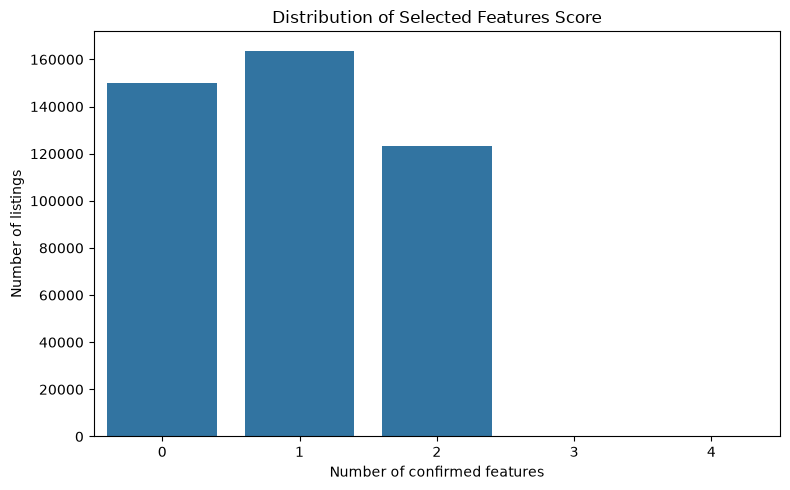

In [205]:
score_counts = df_region["features_score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=score_counts.index,
    y=score_counts.values
)

plt.title("Distribution of Selected Features Score")
plt.xlabel("Number of confirmed features")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

In [206]:
def get_top_regions_by_score(df, score_threshold=4, region_col="region", top_k=15):
    selected_df = df[df["features_score"] >= score_threshold].copy()
    
    top_regions = (
        selected_df
        .groupby(region_col)
        .size()
        .sort_values(ascending=False)
        .head(top_k)
    )
    
    return top_regions

In [207]:
def plot_top_regions_by_score(df, score_threshold=4, region_col="region", top_k=15):
    top_regions = get_top_regions_by_score(
        df, 
        score_threshold, 
        region_col,
        top_k
    )
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        x=top_regions.values,
        y=top_regions.index
    )
    
    plt.title(
        f"Top {top_k} regions for properties with score >= {score_threshold}"
    )
    plt.xlabel("Number of listings")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()

    return top_regions

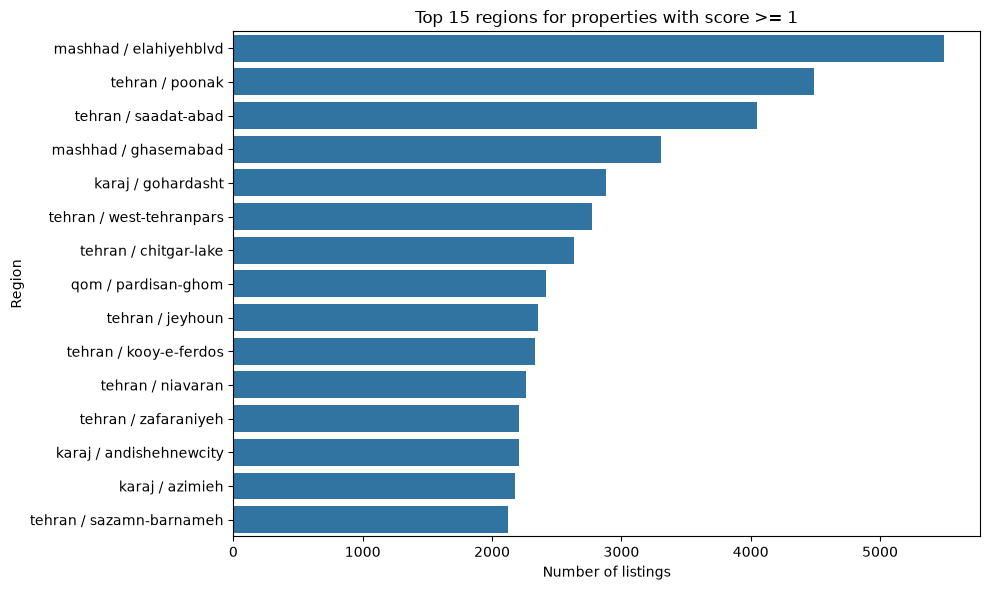

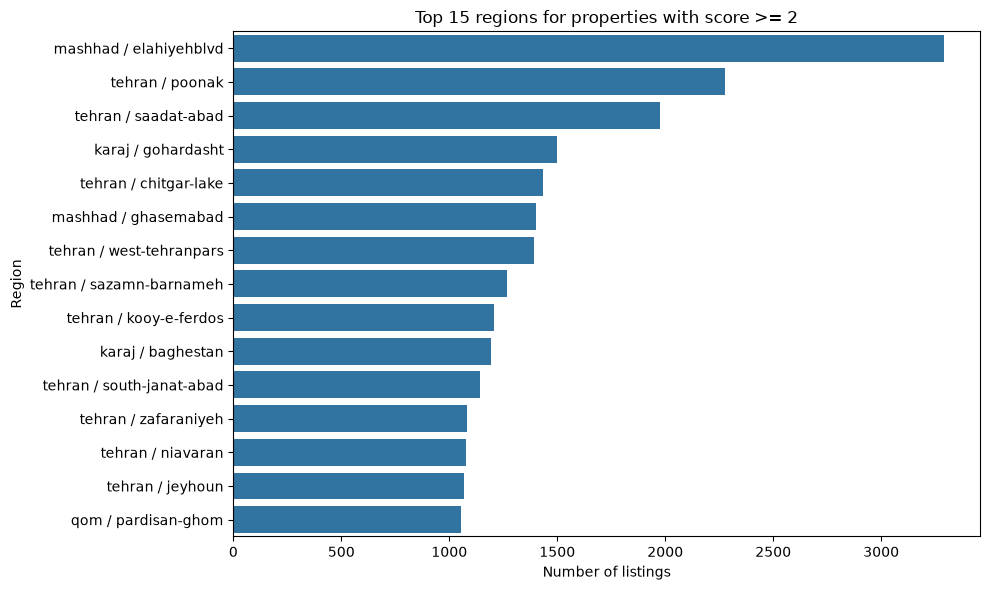

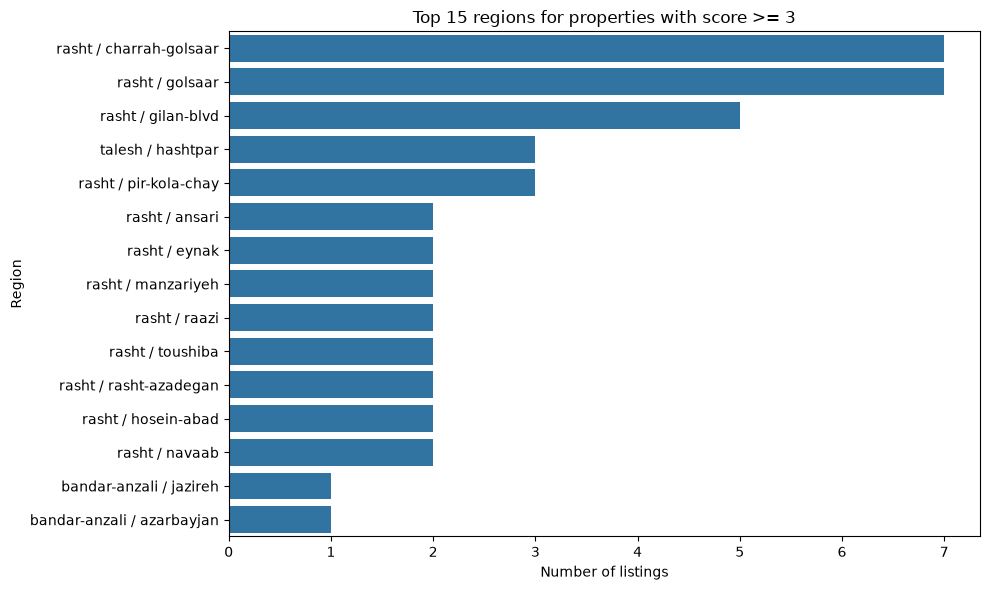

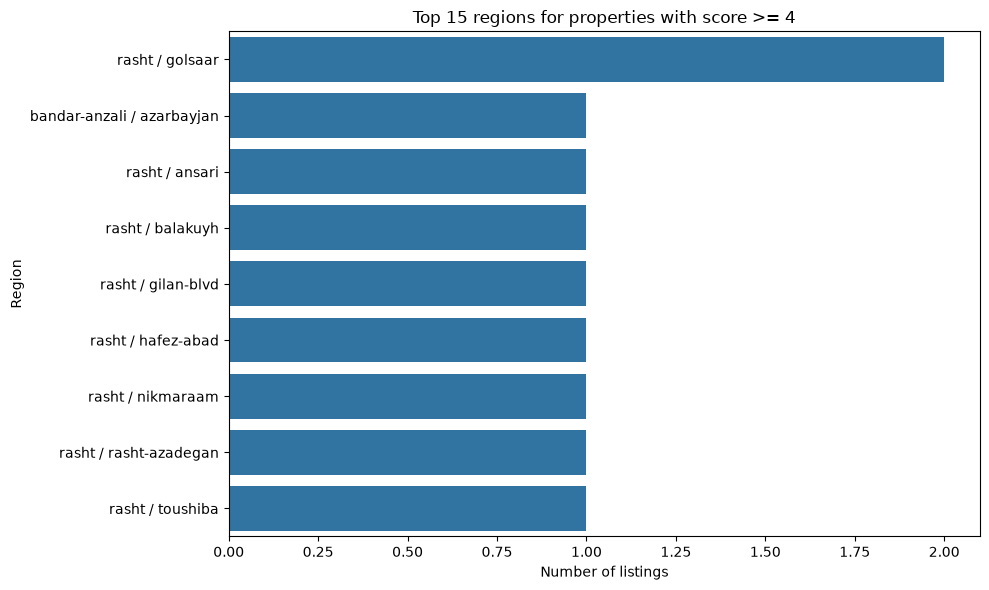

In [208]:
score_threshold_values = [1, 2, 3, 4]

for score_threshold in score_threshold_values:
    plot_top_regions_by_score(
        df=df_region,
        score_threshold=score_threshold,
        region_col="region",
        top_k=15
    )